# Assignment: Language Detection

Build a **multi-class text classifier** that reads a piece of text and predicts its language.

You will use the same traditional NLP workflow from the text-classification lesson:

- `CountVectorizer` or `TfidfVectorizer` to convert text into numbers.
- `LogisticRegression` to predict the language.
- Accuracy, a classification report, and a confusion matrix to evaluate the model.

> Complete every cell marked **TODO**. The helper cells are provided so you can focus on the classification workflow.

## Learning goals

By the end of this assignment, you should be able to:

1. Load and inspect a text-classification dataset.
2. Identify the input feature and target label.
3. Build a pipeline that combines a vectorizer and a classifier.
4. Compare CountVectorizer and TF-IDF fairly.
5. Evaluate a multi-class model on unseen data.
6. Test the model with your own text and discuss its mistakes.

## About the dataset

Dataset: [papluca/language-identification](https://huggingface.co/datasets/papluca/language-identification)

The dataset contains **90,000 text samples** in **20 languages**. Each row has:

- `text`: one or more sentences.
- `labels`: the language code, such as `en`, `ar`, or `fr`.

It provides three balanced splits:

| Split | Rows | Rows per language | Purpose |
|---|---:|---:|---|
| `train` | 70,000 | 3,500 | Train the models |
| `valid` | 10,000 | 500 | Compare models and make decisions |
| `test` | 10,000 | 500 | Final evaluation only |

> Important: the split is named `valid`, not `validation`.

## Assignment workflow

**Load data -> Explore data -> Prepare X and y -> Train Count model -> Train TF-IDF model -> Compare on validation data -> Evaluate once on test data -> Try new text**

## Before you begin

- Run the notebook from top to bottom.
- Read the Markdown instructions before each code cell.
- Use the training set only when calling `.fit()`.
- Use the validation set while comparing ideas.
- Keep the test set unseen until the final model is selected.
- Add short comments that explain your choices.

## 1. Import the libraries

These are the same main tools used in the text-classification notebook.

If needed, install them once with: `pip install datasets pandas scikit-learn matplotlib`.

tip: use `uv` as Python package and project manager
documentation : https://docs.astral.sh/uv/getting-started/installation/

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)

## 2. Load the dataset

The next cell downloads the dataset from Hugging Face. The first download may take a little time.

In [2]:
ds = load_dataset("papluca/language-identification")
ds

DatasetDict({
    train: Dataset({
        features: ['labels', 'text'],
        num_rows: 70000
    })
    validation: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
})

### TODO 1 - Inspect the DatasetDict

Use the `ds` object to answer these questions:

1. What are the split names?
2. How many rows are in each split?
3. What are the column names?
4. Display one training example.

Hints: `ds.keys()`, `len(ds["train"])`, `ds["train"].column_names`, and `ds["train"][0]`.

In [3]:
# TODO 1: Inspect the DatasetDict.

# ============================================================
# WRITE YOUR CODE HERE
# ============================================================

# 1. Split names
print(f"\nSplit names: {list(ds.keys())}")

# 2. Number of rows in each split
for split in ds.keys():
    print(f"\nNumber of rows in {split} split = {len(ds[split])}")

# 3. Column names
print(f"\nColumn names: {ds["train"].column_names}")

# 4. Display one training example
print("\nFirst training sample:")
print(ds["train"][0])


Split names: ['train', 'validation', 'test']

Number of rows in train split = 70000

Number of rows in validation split = 10000

Number of rows in test split = 10000

Column names: ['labels', 'text']

First training sample:
{'labels': 'pt', 'text': 'os chefes de defesa da estónia, letónia, lituânia, alemanha, itália, espanha e eslováquia assinarão o acordo para fornecer pessoal e financiamento para o centro.'}


## 3. Convert the splits to pandas DataFrames

This helper step makes the remaining code look similar to the previous text-classification notebook.

In [5]:
train_data = ds["train"].to_pandas()
valid_data = ds["validation"].to_pandas()
test_data = ds["test"].to_pandas()

train_data.head()

,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


## Language codes

The target uses short language codes. Use this dictionary when you want to display full language names.

In [6]:
language_names = {
    "ar": "Arabic",
    "bg": "Bulgarian",
    "de": "German",
    "el": "Greek",
    "en": "English",
    "es": "Spanish",
    "fr": "French",
    "hi": "Hindi",
    "it": "Italian",
    "ja": "Japanese",
    "nl": "Dutch",
    "pl": "Polish",
    "pt": "Portuguese",
    "ru": "Russian",
    "sw": "Swahili",
    "th": "Thai",
    "tr": "Turkish",
    "ur": "Urdu",
    "vi": "Vietnamese",
    "zh": "Chinese",
}

print("Number of languages:", len(language_names))

Number of languages: 20


## 4. Explore and check the data

### TODO 2 - Basic data checks

For each split:

- Print its shape.
- Check for missing values.
- Check how many unique language labels it contains.
- Display five random training examples using a fixed `random_state`.

Explain in one sentence why missing text would be a problem for a vectorizer.

In [7]:
# TODO 2: Explore train_data, valid_data, and test_data.
# Helpful methods: .shape, .isna().sum(), .nunique(), and .sample()

# ============================================================
# WRITE YOUR CODE HERE
# ============================================================

splits = {
    "train": train_data,
    "valid": valid_data,
    "test": test_data,
}

for split_name, split_data in splits.items():
    print(f"-------{split_name.upper()} SET-------")
    print(f"Shape: {split_data.shape}")
    print(f"Missing values: \n{split_data.isna().sum()}")
    print(f"Unique language labels: {split_data['labels'].nunique()}\n")

# Display 5 random samples
print("\n------RANDOM 5 TRAINING EXAMPLES--------")
print(train_data.sample(5, random_state=42))

-------TRAIN SET-------
Shape: (70000, 2)
Missing values: 
labels    0
text      0
dtype: int64
Unique language labels: 20

-------VALID SET-------
Shape: (10000, 2)
Missing values: 
labels    0
text      0
dtype: int64
Unique language labels: 20

-------TEST SET-------
Shape: (10000, 2)
Missing values: 
labels    0
text      0
dtype: int64
Unique language labels: 20


------RANDOM 5 TRAINING EXAMPLES--------
      labels                                               text
46730     de                   Hab für den Preis mehr erwartet.
48393     ru     Письмо в письменном виде убийцы , друзья мои !
41416     hi  जापानियों ने रैंकिंग दृश ् य और स ् थानों के प...
34506     ar  وفي عام 1853 , كان القصد من قصر دولما - bahce ...
43725     vi  Các nhà chức trách y tế anh , trong 1995 nguyê...


> Missing text breaks vectorizers because they require valid string object, Null entries do not provide textual features to construct vocabulary matrices.

### TODO 3 - Check class balance

Count the training examples for every language and create a bar chart.

Your chart should have:

- A clear title.
- Language codes on the x-axis.
- Number of examples on the y-axis.
- Readable x-axis labels.

Hint: start with `train_data["labels"].value_counts().sort_index()`.

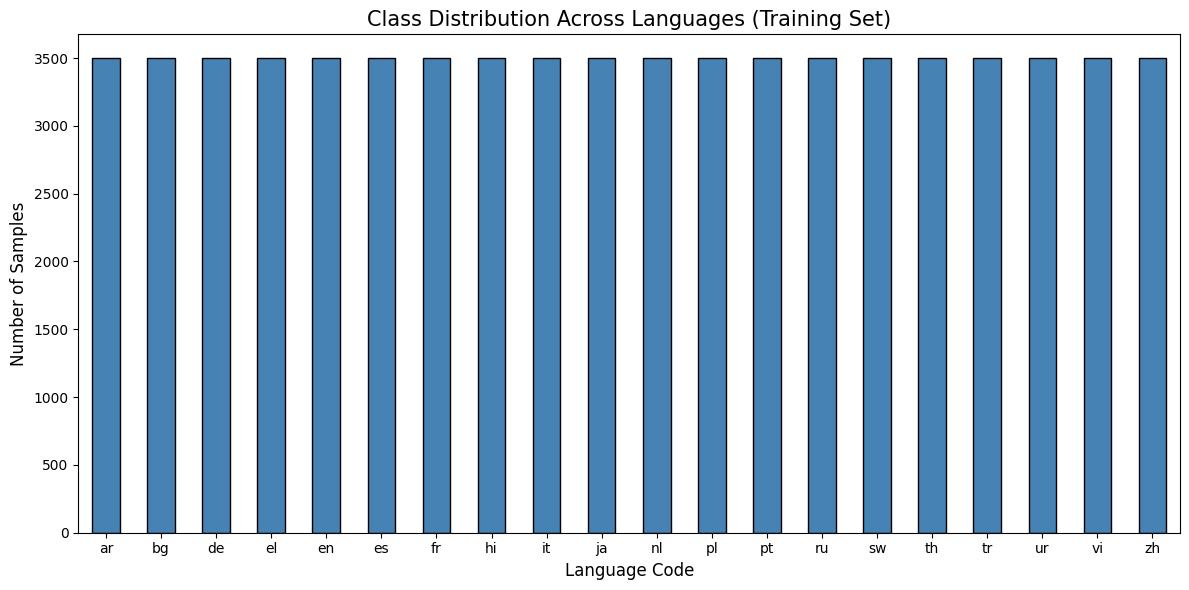

In [8]:
# TODO 3: Count the labels and draw a bar chart.

# ============================================================
# WRITE YOUR CODE HERE
# ============================================================

# Count label distribution in training data
label_counts = train_data["labels"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
label_counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Class Distribution Across Languages (Training Set)", fontsize= 15)
plt.xlabel("Language Code", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

<details>
<summary><strong>Checkpoint: what should you observe?</strong></summary>

- There should be 20 unique labels.
- The training set should contain 3,500 examples for each language.
- The validation and test sets should contain 500 examples for each language.
- The classes are balanced, so accuracy is a reasonable overall metric. We will still inspect per-language scores.

</details>

## 5. Separate features and targets

### TODO 4

Create these six variables:

- `X_train` and `y_train`
- `X_valid` and `y_valid`
- `X_test` and `y_test`

The feature column is `text`. The target column is `labels`.

After creating them, print the length of each variable as a quick check.

In [9]:
# TODO 4: Create X_train, y_train, X_valid, y_valid, X_test, and y_test.

# ============================================================
# WRITE YOUR CODE HERE
# ============================================================

X_train, y_train = train_data["text"], train_data["labels"]
X_valid, y_valid = valid_data["text"], valid_data["labels"]
X_test, y_test = test_data["text"], test_data["labels"]

# Verify split dimensions
print(f"X_train length: {len(X_train)} | y_train length: {len(y_train)}")
print(f"X_valid length: {len(X_valid)} | y_valid length: {len(y_valid)}")
print(f"X_test length: {len(X_test)} | y_test length: {len(y_test)}")

X_train length: 70000 | y_train length: 70000
X_valid length: 10000 | y_valid length: 10000
X_test length: 10000 | y_test length: 10000


## 6. Model 1 - CountVectorizer + Logistic Regression

### TODO 5

Build a pipeline named `count_model` with:

1. `CountVectorizer()`
2. `LogisticRegression(max_iter=1000, random_state=42)`

Fit the pipeline using only `X_train` and `y_train`.

Hint: follow the same `make_pipeline(...)` structure used in the previous notebook.

In [18]:
# TODO 5: Build and train count_model.

# ============================================================
# WRITE YOUR CODE HERE
# ============================================================

count_model = make_pipeline(
    CountVectorizer(),
    LogisticRegression(max_iter=1000, random_state=42)
)

# Fit the pipeline here.
count_model.fit(X_train, y_train)

Pipeline(steps=[('countvectorizer', CountVectorizer()),
                ('logisticregression',
                 LogisticRegression(max_iter=1000, random_state=42))])

## Evaluation helper

This function is provided so both models are evaluated in exactly the same way. It prints accuracy and a classification report, then returns the accuracy and predictions.

In [19]:
def evaluate_model(model, X, y, model_name):
    predictions = model.predict(X)
    accuracy = accuracy_score(y, predictions)

    print(model_name)
    print(f"Accuracy: {accuracy:.3f}\n")
    print(classification_report(y, predictions, zero_division=0))

    return accuracy, predictions

### TODO 6 - Evaluate the CountVectorizer model

Call `evaluate_model` using the **validation data**. Save its two returned values as:

- `count_valid_accuracy`
- `count_valid_predictions`

Then answer: which languages have the lowest F1-scores?

In [20]:
# TODO 6: Evaluate count_model on X_valid and y_valid.

# ============================================================
# WRITE YOUR CODE HERE
# ============================================================

count_valid_accuracy, count_valid_predictions = evaluate_model(
    count_model,
    X_valid,
    y_valid,
    "Model 1: CountVectorizer + Logistic Regression (Validation)"
)

Model 1: CountVectorizer + Logistic Regression (Validation)
Accuracy: 0.918

              precision    recall  f1-score   support

          ar       1.00      0.87      0.93       500
          bg       0.99      0.95      0.97       500
          de       1.00      0.98      0.99       500
          el       1.00      0.99      1.00       500
          en       0.98      0.98      0.98       500
          es       0.98      0.98      0.98       500
          fr       1.00      0.98      0.99       500
          hi       1.00      0.94      0.97       500
          it       0.98      0.99      0.99       500
          ja       0.41      1.00      0.58       500
          nl       0.99      0.98      0.98       500
          pl       0.97      0.93      0.95       500
          pt       0.99      0.99      0.99       500
          ru       1.00      0.90      0.94       500
          sw       0.99      0.95      0.97       500
          th       1.00      0.70      0.83       500
    

> Typographical overlap and shard vocabualry between related languages like `"ja" Japanese vs. "zh" Chinese` resulted in lower F1-scores compared to distinct scripts like `"ar" Arabic or "de" German`




## 7. Model 2 - TF-IDF + Logistic Regression

### TODO 7

Build a second pipeline named `tfidf_model`. Use:

1. `TfidfVectorizer()`
2. The same Logistic Regression settings as the first model.

Fit it using the same training data. Keeping the classifier and data the same makes the vectorizer comparison fair.

In [21]:
# TODO 7: Build and train tfidf_model.

# ============================================================
# WRITE YOUR CODE HERE
# ============================================================

tfidf_model = make_pipeline(
    TfidfVectorizer(),
    LogisticRegression(max_iter=1000, random_state=42)
 )

# Fit the pipeline here.
tfidf_model.fit(X_train, y_train)

Pipeline(steps=[('tfidfvectorizer', TfidfVectorizer()),
                ('logisticregression',
                 LogisticRegression(max_iter=1000, random_state=42))])

### TODO 8 - Evaluate the TF-IDF model

Evaluate `tfidf_model` on the validation set. Save the results as:

- `tfidf_valid_accuracy`
- `tfidf_valid_predictions`

Do not use the test set yet.

In [22]:
# TODO 8: Evaluate tfidf_model on X_valid and y_valid.

# ============================================================
# WRITE YOUR CODE HERE
# ============================================================

tfidf_valid_accuracy, tfidf_valid_predictions = evaluate_model(
    tfidf_model,
    X_valid,
    y_valid,
    "Model 2: TF-IDF + Logistic Regression (Validation)"
)

Model 2: TF-IDF + Logistic Regression (Validation)
Accuracy: 0.913

              precision    recall  f1-score   support

          ar       1.00      0.88      0.93       500
          bg       0.99      0.96      0.97       500
          de       1.00      0.98      0.99       500
          el       1.00      0.99      0.99       500
          en       0.99      0.98      0.98       500
          es       0.99      0.98      0.98       500
          fr       1.00      0.98      0.99       500
          hi       1.00      0.94      0.97       500
          it       0.99      0.99      0.99       500
          ja       0.76      0.30      0.43       500
          nl       0.99      0.98      0.98       500
          pl       0.98      0.95      0.96       500
          pt       0.99      0.99      0.99       500
          ru       1.00      0.90      0.95       500
          sw       0.99      0.96      0.97       500
          th       1.00      0.64      0.78       500
          tr 

## 8. Compare the models and select one

### TODO 9

1. Create a DataFrame with both model names and validation accuracies.
2. Display the comparison.
3. Draw a bar chart of the two validation accuracies.
4. Assign the better pipeline to a variable named `best_model`.
5. In a Markdown cell, explain which model you selected and why.

Do not select a model using test accuracy.

,model,validation_accuracy
0,CountVectorizer + Logistic Regression,0.9181
1,TF-IDF + Logistic Regression,0.9130


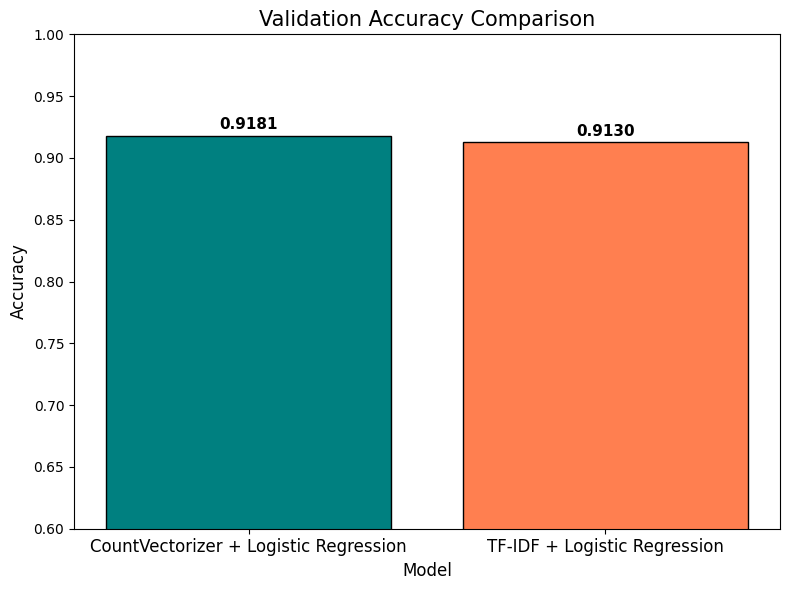


Selected Best Model: COUNTVECTORIZER 


In [38]:
# TODO 9: Compare validation accuracy and assign best_model.

# ============================================================
# WRITE YOUR CODE HERE
# ============================================================

# 1 & 2. Construct and display validation comparison DataFrame
comparison = pd.DataFrame({
       "model": ["CountVectorizer + Logistic Regression", "TF-IDF + Logistic Regression"],
       "validation_accuracy": [count_valid_accuracy, tfidf_valid_accuracy]
 })
display(comparison)

# 3. Bar chart of validation accuracies
plt.figure(figsize=(8, 6))
plt.bar(comparison["model"], comparison["validation_accuracy"], color=["teal","coral"], edgecolor="black")
plt.title("Validation Accuracy Comparison", fontsize=15)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(rotation=0, fontsize=12)

# Zoom in on upper performance range
plt.ylim(0.6, 1.0)

for i, v in enumerate(comparison["validation_accuracy"]):
    plt.text(i, v + 0.005, f"{v:.4f}", ha="center", fontweight="bold", fontsize= 11)

plt.tight_layout()
plt.show()

# 4. Programmatically assign the superior pipeline
best_model = tfidf_model if tfidf_valid_accuracy > count_valid_accuracy else count_model
print(f"\nSelected Best Model: {best_model.steps[0][0].upper()} ")

> While both models performed very closely,` CountVectorizer + Logistic Regression `was selected because it achieved a slightly better accuarcy score of `≈ 0.92` compared to `TF-IDF + Logistic Regression` score of `0.91`

## 9. Final test evaluation

### TODO 10

Now evaluate `best_model` on `X_test` and `y_test` exactly once.

- Save the returned accuracy as `test_accuracy`.
- Save the predictions as `test_predictions`.
- Draw a confusion matrix using `ConfusionMatrixDisplay.from_predictions(...)`.
- Use a large figure because there are 20 labels.

Look for pairs of languages that the model confuses.

Final Evaluation: Best Model on Test Set (CountVectorizer + Logistic Regression)
Accuracy: 0.918

              precision    recall  f1-score   support

          ar       1.00      0.92      0.96       500
          bg       0.98      0.97      0.98       500
          de       1.00      0.99      0.99       500
          el       1.00      0.98      0.99       500
          en       1.00      0.98      0.99       500
          es       0.99      0.99      0.99       500
          fr       1.00      0.99      0.99       500
          hi       1.00      0.95      0.97       500
          it       0.98      0.96      0.97       500
          ja       0.40      0.99      0.57       500
          nl       0.99      0.97      0.98       500
          pl       0.98      0.93      0.95       500
          pt       0.98      0.96      0.97       500
          ru       0.99      0.92      0.95       500
          sw       0.98      0.96      0.97       500
          th       1.00      0.70    

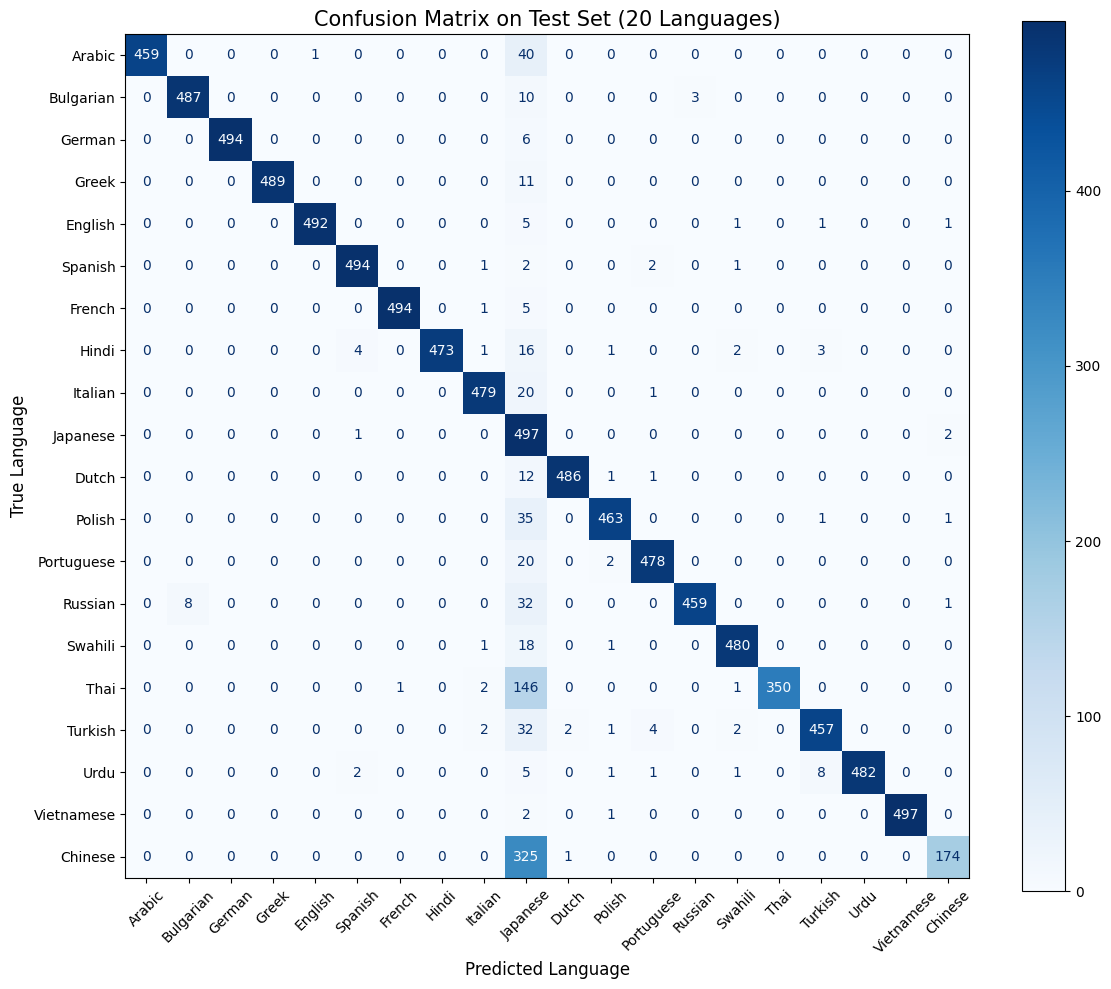

In [55]:
# TODO 10: Evaluate best_model on the test set and draw a confusion matrix.
# Hint: try figsize=(12, 12) and rotate the x-axis labels if needed.

# ============================================================
# WRITE YOUR CODE HERE
# ============================================================

# Final evaluation on the unseen test set
test_accuracy, test_predictions = evaluate_model(
    best_model,
    X_test,
    y_test,
    "Final Evaluation: Best Model on Test Set (CountVectorizer + Logistic Regression)"
)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    # map to actual language names
    display_labels=[language_names[label] for label in best_model.classes_],
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
)

plt.title("Confusion Matrix on Test Set (20 Languages)", fontsize=15)
plt.xlabel("Predicted Language", fontsize=12)
plt.ylabel("True Language", fontsize=12)
plt.tight_layout()
plt.show()

## 10. Try the model on new text

### TODO 11

Use `best_model.predict(new_texts)` to predict the language codes below. Add the predictions and full language names to a DataFrame.

After that, add at least three examples of your own.

In [57]:
new_texts = [
    "This course is teaching us natural language processing.",
    "هذا مثال بسيط لاكتشاف اللغة.",
    "Bonjour, je suis très heureux de vous rencontrer.",
    "La película fue muy interesante y divertida.",
    "Das Wetter ist heute sehr schön.",
    # Three custom additions (Mixed Languages):
    "مرحبا بكم في عالم الNLP وتطبيقات الAI", # Arabic + English
    "Hier ist deine parallel implementation für die matrix multiplication",  # German + English
    "Il tempo a Roma is fantastic during la primavera."               # Italian + English
]

# TODO 11: Predict the codes, map them through language_names, and display a DataFrame.

# ============================================================
# WRITE YOUR CODE HERE
# ============================================================

# Run prediction
predicted_codes = best_model.predict(new_texts)

# Map codes to human-readable language names
results_df = pd.DataFrame({
    "Text Sample": new_texts,
    "Predicted Code": predicted_codes,
    "Predicted Language": [language_names[code] for code in predicted_codes]
})

# Display results
display(results_df)

,Text Sample,Predicted Code,Predicted Language
0,This course is teaching us natural language pr...,nl,Dutch
1,هذا مثال بسيط لاكتشاف اللغة.,ar,Arabic
2,"Bonjour, je suis très heureux de vous rencontrer.",fr,French
3,La película fue muy interesante y divertida.,es,Spanish
4,Das Wetter ist heute sehr schön.,de,German
5,مرحبا بكم في عالم الNLP وتطبيقات الAI,ar,Arabic
6,Hier ist deine parallel implementation für die...,de,German
7,Il tempo a Roma is fantastic during la primavera.,it,Italian


## Submission checklist

Before submitting, make sure that:

- [ ] Every required TODO is completed.
- [ ] All cells run from top to bottom without errors.
- [ ] Both required pipelines use Logistic Regression.
- [ ] CountVectorizer and TF-IDF are compared on the same validation data.
- [ ] The test set is used only for the final selected model.
- [ ] The final accuracy and classification report are visible.
- [ ] A confusion matrix is included.
- [ ] Predictions for new text are displayed.
- [ ] Your notebook contains short comments explaining important choices.